# Sprint 1 — DGraphFin Data & Graph EDA

**Phạm vi:** chuẩn bị dữ liệu đáng tin cậy và graph sẵn sàng cho modeling. Sprint 1
chưa huấn luyện model.

## Câu hỏi nghiên cứu

1. File DGraphFin có đúng schema và các split có tách biệt không?
2. Bài toán mất cân bằng đến mức nào và nên dùng metric gì?
3. Giá trị `-1` xuất hiện ra sao trong 17 feature ẩn danh?
4. Graph có đặc điểm gì về hướng cạnh, degree, edge type và timestamp?
5. Neighbor sampling hai lớp có phù hợp với tài nguyên CPU không?

In [1]:
from dataclasses import dataclass, field
from pathlib import Path
import hashlib
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    """Find the repository root without depending on the notebook launch folder."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "data").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Không tìm thấy project root chứa data/ và notebooks/")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PATH = PROJECT_ROOT / "data" / "dgraphfin.npz"
METRIC_DIR = PROJECT_ROOT / "artifacts" / "metrics"
METRIC_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)

print("Dataset:", DATA_PATH.relative_to(PROJECT_ROOT).as_posix())

Dataset: data/dgraphfin.npz


## 1. Data contract và load dataset

Ba trường có hậu tố `_mask` trong file gốc thực chất là **mảng node index**, không
phải boolean mask. Feature được đổi sang `float32` ngay khi load để giảm gần một nửa
bộ nhớ so với `float64`.

In [2]:
REQUIRED_KEYS = (
    "x", "y", "edge_index", "edge_type", "edge_timestamp",
    "train_mask", "valid_mask", "test_mask",
)
FEATURE_DIMENSION = 17


@dataclass(slots=True)
class DGraphDataset:
    """Canonical in-memory representation of DGraphFin."""

    x: np.ndarray
    y: np.ndarray
    edge_index: np.ndarray
    edge_type: np.ndarray
    edge_timestamp: np.ndarray
    train_mask: np.ndarray
    valid_mask: np.ndarray
    test_mask: np.ndarray

    @property
    def num_nodes(self) -> int:
        return int(self.x.shape[0])

    @property
    def num_edges(self) -> int:
        return int(self.edge_index.shape[0])


def load_dgraphfin(path: str | Path) -> DGraphDataset:
    """Load required arrays and use memory-conscious canonical dtypes."""
    dataset_path = Path(path)
    if not dataset_path.is_file():
        raise FileNotFoundError(f"Không tìm thấy dataset: {dataset_path}")

    with np.load(dataset_path, allow_pickle=False) as archive:
        missing = sorted(set(REQUIRED_KEYS) - set(archive.files))
        if missing:
            raise ValueError(f"Dataset thiếu trường bắt buộc: {missing}")
        return DGraphDataset(
            x=np.asarray(archive["x"], dtype=np.float32),
            y=np.asarray(archive["y"], dtype=np.int64),
            edge_index=np.asarray(archive["edge_index"], dtype=np.int64),
            edge_type=np.asarray(archive["edge_type"], dtype=np.int64),
            edge_timestamp=np.asarray(archive["edge_timestamp"], dtype=np.int64),
            train_mask=np.asarray(archive["train_mask"], dtype=np.int64),
            valid_mask=np.asarray(archive["valid_mask"], dtype=np.int64),
            test_mask=np.asarray(archive["test_mask"], dtype=np.int64),
        )


load_started = time.perf_counter()
dataset = load_dgraphfin(DATA_PATH)
load_seconds = time.perf_counter() - load_started
print(f"Loaded in {load_seconds:.3f} seconds")

Loaded in 0.574 seconds


In [3]:
arrays = {
    "x": dataset.x,
    "y": dataset.y,
    "edge_index": dataset.edge_index,
    "edge_type": dataset.edge_type,
    "edge_timestamp": dataset.edge_timestamp,
    "train_mask": dataset.train_mask,
    "valid_mask": dataset.valid_mask,
    "test_mask": dataset.test_mask,
}
schema_df = pd.DataFrame(
    [
        {
            "field": name,
            "shape": str(value.shape),
            "dtype": str(value.dtype),
            "memory_MiB": value.nbytes / 1024**2,
        }
        for name, value in arrays.items()
    ]
)
display(schema_df.round({"memory_MiB": 2}))
print(f"Canonical arrays: {sum(value.nbytes for value in arrays.values()) / 1024**2:.1f} MiB")

,field,shape,dtype,memory_MiB
0,x,"(3700550, 17)",float32,239.98
1,y,"(3700550,)",int64,28.23
2,edge_index,"(4300999, 2)",int64,65.63
3,edge_type,"(4300999,)",int64,32.81
4,edge_timestamp,"(4300999,)",int64,32.81
5,train_mask,"(857899,)",int64,6.55
6,valid_mask,"(183862,)",int64,1.40
7,test_mask,"(183840,)",int64,1.40


Canonical arrays: 408.8 MiB


## 2. Kiểm định tính toàn vẹn

Validator kiểm tra shape, miền node ID, nhãn, giá trị hữu hạn, phần tử trùng và sự
chồng lấn giữa các split. Việc kiểm tra feature được chia chunk để không tạo thêm một
boolean array khổng lồ.

In [4]:
@dataclass(slots=True)
class ValidationReport:
    errors: list[str] = field(default_factory=list)
    warnings: list[str] = field(default_factory=list)

    @property
    def is_valid(self) -> bool:
        return not self.errors

    def as_dict(self) -> dict[str, object]:
        return {"is_valid": self.is_valid, "errors": self.errors, "warnings": self.warnings}


def validate_split_indices(
    name: str,
    indices: np.ndarray,
    num_nodes: int,
    seen: np.ndarray,
    report: ValidationReport,
) -> None:
    """Validate one index-based split and update the shared coverage mask."""
    if indices.ndim != 1 or not np.issubdtype(indices.dtype, np.integer):
        report.errors.append(f"{name} phải là mảng chỉ số nguyên một chiều")
        return
    if indices.size == 0:
        report.errors.append(f"{name} không được rỗng")
        return
    if int(indices.min()) < 0 or int(indices.max()) >= num_nodes:
        report.errors.append(f"{name} chứa node ID ngoài miền [0, {num_nodes})")
        return

    unique_indices = np.unique(indices)
    if unique_indices.size != indices.size:
        report.errors.append(f"{name} chứa node ID trùng lặp")
    if np.any(seen[unique_indices]):
        report.errors.append(f"{name} chồng lấn với split đã kiểm tra")
    seen[unique_indices] = True


def validate_dataset(dataset: DGraphDataset, chunk_size: int = 250_000) -> ValidationReport:
    """Validate schema, ranges, labels, finite features and split isolation."""
    report = ValidationReport()
    num_nodes, num_edges = dataset.num_nodes, dataset.num_edges

    expected_shapes = {
        "y": (num_nodes,),
        "edge_index": (num_edges, 2),
        "edge_type": (num_edges,),
        "edge_timestamp": (num_edges,),
    }
    if dataset.x.ndim != 2 or dataset.x.shape[1] != FEATURE_DIMENSION:
        report.errors.append(f"x phải có shape (N, {FEATURE_DIMENSION}), nhận {dataset.x.shape}")
    for name, expected_shape in expected_shapes.items():
        actual_shape = getattr(dataset, name).shape
        if actual_shape != expected_shape:
            report.errors.append(f"{name} phải có shape {expected_shape}, nhận {actual_shape}")

    for start in range(0, num_nodes, chunk_size):
        if not np.isfinite(dataset.x[start : start + chunk_size]).all():
            report.errors.append("x chứa NaN hoặc Inf")
            break

    labels = np.unique(dataset.y)
    if not np.isin(labels, [0, 1, 2, 3]).all():
        report.errors.append(f"y chứa nhãn ngoài miền 0..3: {labels.tolist()}")
    if num_edges:
        edge_min, edge_max = int(dataset.edge_index.min()), int(dataset.edge_index.max())
        if edge_min < 0 or edge_max >= num_nodes:
            report.errors.append(f"edge_index chứa node ID ngoài miền [0, {num_nodes})")
        if int(dataset.edge_type.min()) < 0:
            report.errors.append("edge_type chứa giá trị âm")

    seen = np.zeros(num_nodes, dtype=np.bool_)
    for split_name in ("train_mask", "valid_mask", "test_mask"):
        validate_split_indices(
            split_name, getattr(dataset, split_name), num_nodes, seen, report
        )

    split_indices = np.concatenate(
        (dataset.train_mask, dataset.valid_mask, dataset.test_mask)
    )
    if not np.isin(dataset.y[split_indices], [0, 1]).all():
        report.errors.append("Split dự đoán chứa node không thuộc lớp 0/1")
    labeled_count = int(np.count_nonzero(np.isin(dataset.y, [0, 1])))
    if int(seen.sum()) != labeled_count:
        report.warnings.append(
            f"Ba split bao phủ {int(seen.sum())}/{labeled_count} node lớp 0/1"
        )
    return report

In [5]:
validation = validate_dataset(dataset)
display(pd.DataFrame([validation.as_dict()]))
assert validation.is_valid, validation.errors
print("Dataset hợp lệ; có thể tiếp tục EDA.")

,is_valid,errors,warnings
0,True,[],[]


Dataset hợp lệ; có thể tiếp tục EDA.


## 3. Quy mô, nhãn và split

Fraud chỉ chiếm tỷ lệ rất nhỏ trong các node mục tiêu. Vì vậy accuracy có thể gây
hiểu nhầm; phần modeling sẽ ưu tiên **Average Precision (AP)** và báo cáo thêm ROC-AUC.

In [6]:
def value_counts(values: np.ndarray) -> dict[str, int]:
    keys, counts = np.unique(values, return_counts=True)
    return {
        str(int(key)): int(count)
        for key, count in zip(keys, counts, strict=True)
    }


def profile_dataset(dataset: DGraphDataset) -> dict[str, object]:
    """Create JSON-serializable statistics used by the report."""
    split_profiles = {}
    for field_name in ("train_mask", "valid_mask", "test_mask"):
        indices = getattr(dataset, field_name)
        split_profiles[field_name.removesuffix("_mask")] = {
            "node_count": int(indices.size),
            "label_counts": value_counts(dataset.y[indices]),
        }

    source, target = dataset.edge_index[:, 0], dataset.edge_index[:, 1]
    out_degree = np.bincount(source, minlength=dataset.num_nodes)
    in_degree = np.bincount(target, minlength=dataset.num_nodes)
    feature_profiles = []
    for feature_index in range(dataset.x.shape[1]):
        values = dataset.x[:, feature_index]
        feature_profiles.append(
            {
                "feature": feature_index,
                "min": float(values.min()),
                "max": float(values.max()),
                "mean": float(values.mean(dtype=np.float64)),
                "std": float(values.std(dtype=np.float64)),
                "minus_one_count": int(np.count_nonzero(values == -1)),
            }
        )

    profile = {
        "num_nodes": dataset.num_nodes,
        "num_edges": dataset.num_edges,
        "feature_dimension": int(dataset.x.shape[1]),
        "feature_dtype": str(dataset.x.dtype),
        "feature_min": float(dataset.x.min()),
        "feature_max": float(dataset.x.max()),
        "features": feature_profiles,
        "label_counts": value_counts(dataset.y),
        "splits": split_profiles,
        "edge_type_counts": value_counts(dataset.edge_type),
        "timestamp": {
            "min": int(dataset.edge_timestamp.min()),
            "max": int(dataset.edge_timestamp.max()),
            "unique_count": int(np.unique(dataset.edge_timestamp).size),
        },
        "directed_graph": {
            "self_loop_count": int(np.count_nonzero(source == target)),
            "isolated_node_count": int(np.count_nonzero((in_degree + out_degree) == 0)),
            "max_in_degree": int(in_degree.max()),
            "max_out_degree": int(out_degree.max()),
            "mean_in_degree": float(in_degree.mean()),
            "mean_out_degree": float(out_degree.mean()),
        },
    }
    return profile, in_degree, out_degree


profile, in_degree, out_degree = profile_dataset(dataset)

In [7]:
label_names = {0: "Normal", 1: "Fraud", 2: "Background-2", 3: "Background-3"}
label_counts = pd.Series(profile["label_counts"], dtype="int64")
label_counts.index = label_counts.index.astype(int)
label_df = label_counts.rename("count").to_frame()
label_df["label"] = label_df.index.map(label_names)
label_df["percentage_all_nodes"] = label_df["count"] / dataset.num_nodes * 100
display(label_df[["label", "count", "percentage_all_nodes"]].round(4))

split_rows = []
for split_name, split_profile in profile["splits"].items():
    normal = split_profile["label_counts"].get("0", 0)
    fraud = split_profile["label_counts"].get("1", 0)
    split_rows.append(
        {
            "split": split_name,
            "nodes": split_profile["node_count"],
            "normal": normal,
            "fraud": fraud,
            "fraud_rate_%": fraud / (normal + fraud) * 100,
        }
    )
split_df = pd.DataFrame(split_rows).set_index("split")
display(split_df.round(4))

,label,count,percentage_all_nodes
0,Normal,1210092,32.7003
1,Fraud,15509,0.4191
2,Background-2,1620851,43.8003
3,Background-3,854098,23.0803


,nodes,normal,fraud,fraud_rate_%
split,,,,
train,857899,847042,10857,1.2655
valid,183862,181536,2326,1.2651
test,183840,181514,2326,1.2652


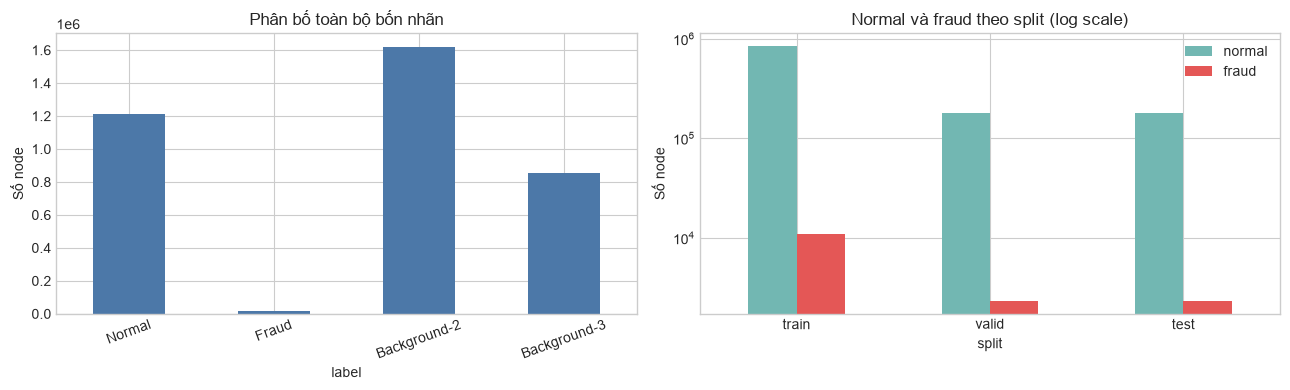

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
label_df.set_index("label")["count"].plot.bar(ax=axes[0], color="#4C78A8")
axes[0].set_title("Phân bố toàn bộ bốn nhãn")
axes[0].set_ylabel("Số node")
axes[0].tick_params(axis="x", rotation=20)

split_df[["normal", "fraud"]].plot.bar(ax=axes[1], logy=True, color=["#72B7B2", "#E45756"])
axes[1].set_title("Normal và fraud theo split (log scale)")
axes[1].set_ylabel("Số node")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 4. Missing sentinel và phân phối feature

Paper DGraph mô tả `-1` như missing sentinel. Ta đo tỷ lệ xuất hiện theo từng feature
và chỉ dùng **train split** khi quan sát phân phối phục vụ quyết định modeling.

,feature,min,max,mean,std,minus_one_count,minus_one_rate_%
0,0,-1.0,1.000,0.5077,0.7378,544771,14.7214
1,1,-1.0,8.000,3.0772,2.6346,546549,14.7694
2,2,-1.0,153.510,-0.0881,1.4313,2004522,54.1682
3,3,-1.0,153.375,-0.1588,1.3125,2005918,54.2059
4,4,-1.0,1.000,-0.1536,0.9248,2005918,54.2059
5,5,-1.0,456.300,-0.2029,1.3291,2145612,57.9809
6,6,-1.0,68.646,0.0877,1.9130,2004522,54.1682
7,7,-1.0,12.679,-0.5120,0.6152,2145612,57.9809
8,8,-1.0,68.027,0.0667,1.8746,2005918,54.2059
9,9,-1.0,1.000,-0.1076,0.9721,2005918,54.2059


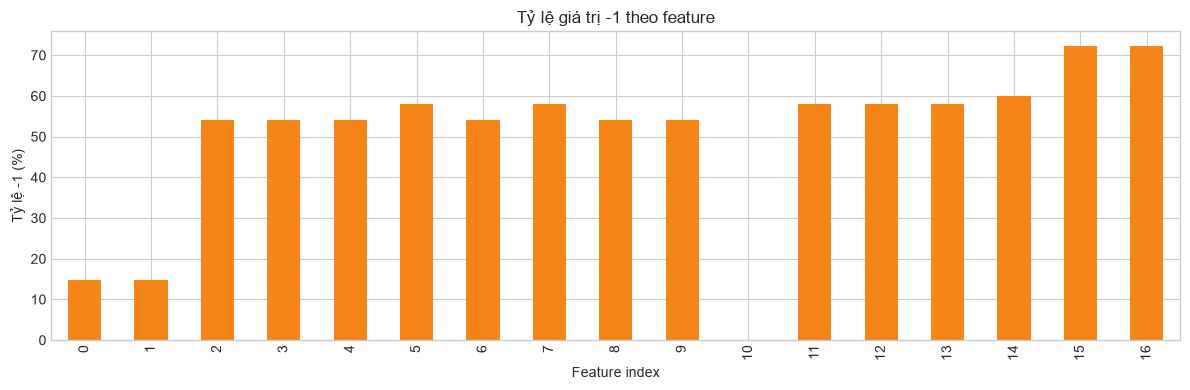

In [9]:
feature_df = pd.DataFrame(profile["features"])
feature_df["minus_one_rate_%"] = feature_df["minus_one_count"] / dataset.num_nodes * 100
display(feature_df.round(4))

ax = feature_df.plot.bar(
    x="feature", y="minus_one_rate_%", figsize=(12, 4), legend=False, color="#F58518"
)
ax.set_title("Tỷ lệ giá trị -1 theo feature")
ax.set_xlabel("Feature index")
ax.set_ylabel("Tỷ lệ -1 (%)")
plt.tight_layout()
plt.show()

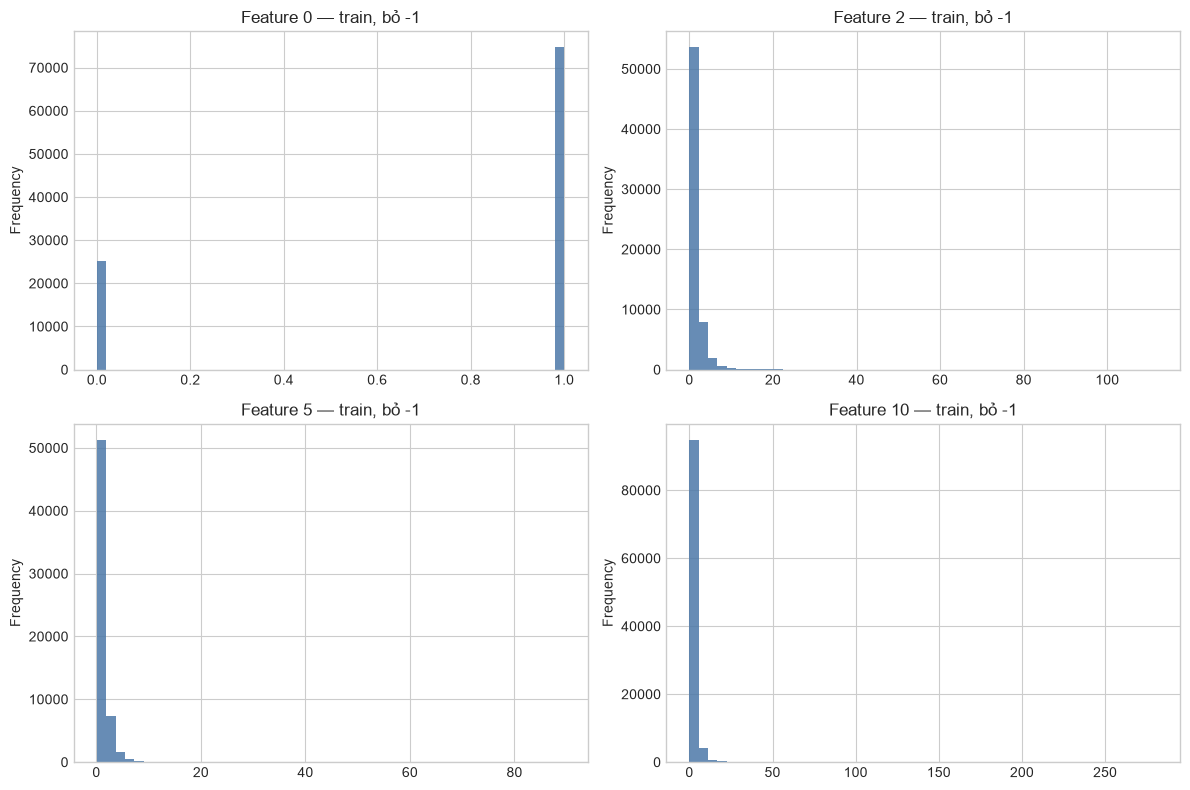

In [10]:
rng = np.random.default_rng(42)
sample_size = min(100_000, dataset.train_mask.size)
sampled_train = rng.choice(dataset.train_mask, size=sample_size, replace=False)
selected_features = [0, 2, 5, 10]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for feature_index, ax in zip(selected_features, axes.flat, strict=True):
    values = dataset.x[sampled_train, feature_index]
    observed = values[values != -1]
    ax.hist(observed, bins=50, color="#4C78A8", alpha=0.85)
    ax.set_title(f"Feature {feature_index} — train, bỏ -1")
    ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

## 5. Cấu trúc graph có hướng

`edge_index` gốc có shape `(E, 2)` theo thứ tự `(source, target)`. Dữ liệu canonical
giữ nguyên hướng; biến thể vô hướng chỉ được xem là một ablation ở Sprint 2.

,in_degree,out_degree
count,3700550.000,3700550.000
mean,1.162,1.162
std,1.552,1.290
min,0.000,0.000
50%,1.000,1.000
90%,2.000,3.000
99%,5.000,5.000
99.9%,9.000,6.000
max,882.000,6.000


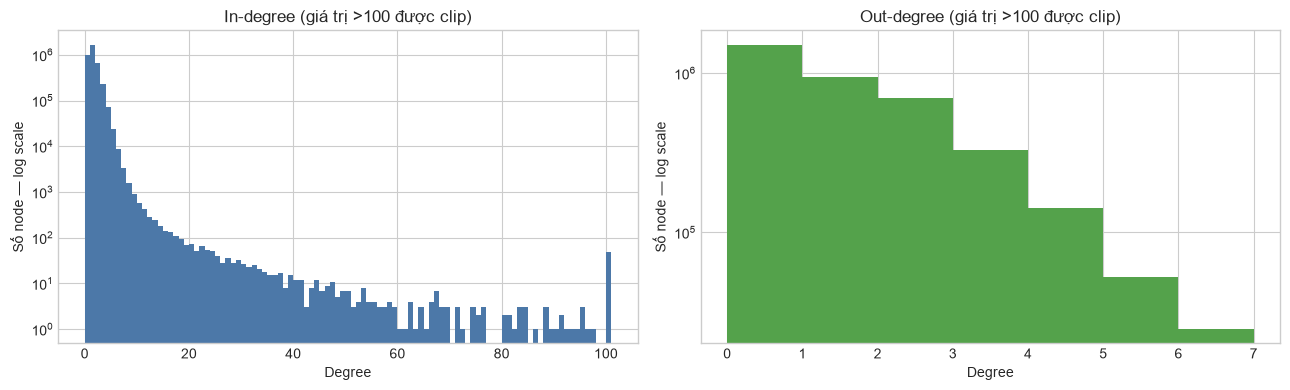

In [11]:
degree_summary = pd.DataFrame(
    {
        "in_degree": pd.Series(in_degree).describe(percentiles=[0.5, 0.9, 0.99, 0.999]),
        "out_degree": pd.Series(out_degree).describe(percentiles=[0.5, 0.9, 0.99, 0.999]),
    }
)
display(degree_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for degree, title, ax, color in (
    (in_degree, "In-degree", axes[0], "#4C78A8"),
    (out_degree, "Out-degree", axes[1], "#54A24B"),
):
    bins = np.arange(0, min(int(degree.max()), 100) + 2)
    ax.hist(np.clip(degree, 0, 100), bins=bins, log=True, color=color)
    ax.set_title(f"{title} (giá trị >100 được clip)")
    ax.set_xlabel("Degree")
    ax.set_ylabel("Số node — log scale")
plt.tight_layout()
plt.show()

In [12]:
edge_type_df = pd.Series(profile["edge_type_counts"], name="count", dtype="int64").to_frame()
edge_type_df.index.name = "edge_type"
display(edge_type_df)

is_target = dataset.y <= 1
source_target = is_target[dataset.edge_index[:, 0]]
destination_target = is_target[dataset.edge_index[:, 1]]
relation_id = (~source_target).astype(np.int8) * 2 + (~destination_target).astype(np.int8)
relation_names = {0: "T→T", 1: "T→B", 2: "B→T", 3: "B→B"}
relation_values, relation_counts = np.unique(relation_id, return_counts=True)
relation_df = pd.DataFrame(
    {
        "relation": [relation_names[int(value)] for value in relation_values],
        "count": relation_counts,
    }
)
display(relation_df)

print("Timestamp:", profile["timestamp"])
print("Directed graph:", profile["directed_graph"])

,count
edge_type,
1,362904
2,51421
3,149977
4,911655
5,1604218
6,645389
7,15882
8,84338
9,125026


,relation,count
0,T→T,746271
1,T→B,1356540
2,B→T,679410
3,B→B,1518778


Timestamp: {'min': 1, 'max': 821, 'unique_count': 821}
Directed graph: {'self_loop_count': 0, 'isolated_node_count': 0, 'max_in_degree': 882, 'max_out_degree': 6, 'mean_in_degree': 1.1622593938738837, 'mean_out_degree': 1.1622593938738837}


## 6. Normal vs. fraud: bốn tín hiệu phân biệt

Phần này tái hiện bốn góc nhìn trong Section 4.2 của
[DGraph paper](https://proceedings.neurips.cc/paper_files/paper/2022/file/8f1918f71972789db39ec0d85bb31110-Paper-Datasets_and_Benchmarks.pdf),
nhưng mọi giá trị bên dưới đều được tính lại trực tiếp từ file DGraphFin đang dùng:

1. Cấu trúc mạng qua in-degree và out-degree;
2. Cosine similarity giữa feature của node và các hàng xóm theo từng hướng;
3. Phân phối số missing sentinel `-1` trên mỗi node;
4. Khoảng thời gian trung bình giữa các out-edge theo out-degree.

Chỉ node nhãn `0` (normal) và `1` (fraud) được dùng để tạo hai nhóm so sánh. Node
background vẫn có thể xuất hiện như hàng xóm khi tính degree và neighbor similarity.
Đây là phân tích mô tả, chưa phải bằng chứng nhân quả hoặc kết quả của temporal model.

In [13]:
GROUP_ORDER = ("Fraud", "Normal")
GROUP_LABELS = {"Fraud": 1, "Normal": 0}
GROUP_COLORS = {"Fraud": "#E98C8C", "Normal": "#78A9D4"}


def mean_and_standard_error(values: np.ndarray) -> tuple[float, float]:
    # Return the mean and standard error for one non-empty 1D sample.
    sample = np.asarray(values, dtype=np.float64)
    if sample.ndim != 1 or sample.size == 0:
        raise ValueError("values must be a non-empty 1D array")
    standard_error = (
        float(sample.std(ddof=1) / np.sqrt(sample.size)) if sample.size > 1 else 0.0
    )
    return float(sample.mean()), standard_error


# (a) Mean in/out degree over every node in each target class.
structure_rows = []
for group_name in GROUP_ORDER:
    group_mask = dataset.y == GROUP_LABELS[group_name]
    for direction, values in (("In-edge", in_degree), ("Out-edge", out_degree)):
        mean, standard_error = mean_and_standard_error(values[group_mask])
        structure_rows.append(
            {
                "group": group_name,
                "direction": direction,
                "mean_degree": mean,
                "standard_error": standard_error,
                "node_count": int(group_mask.sum()),
            }
        )
structure_df = pd.DataFrame(structure_rows)


# (c) Per-class distribution of the number of -1 sentinels on each node.
missing_per_node = np.count_nonzero(dataset.x == -1, axis=1)
missing_rows = []
for group_name in GROUP_ORDER:
    group_values = missing_per_node[dataset.y == GROUP_LABELS[group_name]]
    counts = np.bincount(group_values, minlength=FEATURE_DIMENSION + 1)
    proportions = counts / group_values.size
    for missing_count, (count, proportion) in enumerate(
        zip(counts, proportions, strict=True)
    ):
        missing_rows.append(
            {
                "group": group_name,
                "missing_count": missing_count,
                "node_count": int(count),
                "proportion": float(proportion),
            }
        )
missing_distribution_df = pd.DataFrame(missing_rows)

In [14]:
def neighbor_cosine_similarity_by_direction(
    features: np.ndarray,
    edge_index: np.ndarray,
    in_degree: np.ndarray,
    out_degree: np.ndarray,
    *,
    chunk_size: int = 250_000,
) -> tuple[np.ndarray, np.ndarray]:
    # Compute each node's mean incoming/outgoing neighbor cosine similarity.
    # Edges are processed in chunks to avoid materializing two full (E, F) arrays.
    # A node with no neighbor in one direction receives similarity zero in that
    # direction before the label-group average, matching the paper-style statistic.
    node_norm = np.linalg.norm(features, axis=1)
    incoming_sum = np.zeros(features.shape[0], dtype=np.float64)
    outgoing_sum = np.zeros(features.shape[0], dtype=np.float64)
    source_nodes, target_nodes = edge_index[:, 0], edge_index[:, 1]

    for start in range(0, edge_index.shape[0], chunk_size):
        stop = min(start + chunk_size, edge_index.shape[0])
        source = source_nodes[start:stop]
        target = target_nodes[start:stop]
        dot_product = np.einsum(
            "ij,ij->i", features[source], features[target], optimize=True
        )
        denominator = node_norm[source] * node_norm[target]
        similarity = np.divide(
            dot_product,
            denominator,
            out=np.zeros_like(dot_product),
            where=denominator > 0,
        )
        np.add.at(outgoing_sum, source, similarity)
        np.add.at(incoming_sum, target, similarity)

    incoming_mean = np.divide(
        incoming_sum,
        in_degree,
        out=np.zeros(features.shape[0], dtype=np.float64),
        where=in_degree > 0,
    )
    outgoing_mean = np.divide(
        outgoing_sum,
        out_degree,
        out=np.zeros(features.shape[0], dtype=np.float64),
        where=out_degree > 0,
    )
    return incoming_mean, outgoing_mean


neighbor_in_similarity, neighbor_out_similarity = neighbor_cosine_similarity_by_direction(
    dataset.x, dataset.edge_index, in_degree, out_degree
)

similarity_rows = []
for group_name in GROUP_ORDER:
    group_mask = dataset.y == GROUP_LABELS[group_name]
    for direction, values, degrees in (
        ("In-edge", neighbor_in_similarity, in_degree),
        ("Out-edge", neighbor_out_similarity, out_degree),
    ):
        group_values = values[group_mask]
        group_degrees = degrees[group_mask]
        mean, standard_error = mean_and_standard_error(group_values)
        connected_values = group_values[group_degrees > 0]
        similarity_rows.append(
            {
                "group": group_name,
                "direction": direction,
                "paper_style_mean": mean,
                "standard_error": standard_error,
                "connected_node_mean": float(connected_values.mean()),
                "connected_node_rate": float(np.mean(group_degrees > 0)),
            }
        )
similarity_df = pd.DataFrame(similarity_rows)

In [15]:
def outgoing_time_interval_by_degree(
    edge_index: np.ndarray,
    edge_timestamp: np.ndarray,
    labels: np.ndarray,
    out_degree: np.ndarray,
    degrees: tuple[int, ...] = (2, 3, 4, 5),
) -> pd.DataFrame:
    # Summarize the mean consecutive timestamp gap of each node's out-edges.
    source = edge_index[:, 0]
    order = np.lexsort((edge_timestamp, source))
    sorted_source = source[order]
    sorted_timestamp = edge_timestamp[order]

    same_source = sorted_source[1:] == sorted_source[:-1]
    gap_source = sorted_source[1:][same_source]
    consecutive_gap = (sorted_timestamp[1:] - sorted_timestamp[:-1])[same_source]
    gap_sum = np.bincount(
        gap_source,
        weights=consecutive_gap,
        minlength=labels.size,
    )
    node_mean_gap = np.divide(
        gap_sum,
        out_degree - 1,
        out=np.full(labels.size, np.nan, dtype=np.float64),
        where=out_degree >= 2,
    )

    rows = []
    for degree in degrees:
        for group_name in GROUP_ORDER:
            group_mask = (
                (labels == GROUP_LABELS[group_name]) & (out_degree == degree)
            )
            mean, standard_error = mean_and_standard_error(node_mean_gap[group_mask])
            rows.append(
                {
                    "group": group_name,
                    "out_degree": degree,
                    "mean_interval": mean,
                    "standard_error": standard_error,
                    "node_count": int(group_mask.sum()),
                }
            )
    return pd.DataFrame(rows)


temporal_interval_df = outgoing_time_interval_by_degree(
    dataset.edge_index,
    dataset.edge_timestamp,
    dataset.y,
    out_degree,
)

In [16]:
display(
    structure_df.pivot(index="direction", columns="group", values="mean_degree")
    .loc[["In-edge", "Out-edge"], list(GROUP_ORDER)]
    .round(4)
)
display(similarity_df.round(4))
display(
    missing_distribution_df[
        missing_distribution_df["missing_count"].isin([0, 14])
    ].pivot(index="missing_count", columns="group", values="proportion")
    .loc[:, list(GROUP_ORDER)]
    .round(4)
)
display(temporal_interval_df.round(4))

group,Fraud,Normal
direction,,
In-edge,1.2077,1.1627
Out-edge,0.7472,1.7282


,group,direction,paper_style_mean,standard_error,connected_node_mean,connected_node_rate
0,Fraud,In-edge,0.3918,0.0032,0.5108,0.7670
1,Fraud,Out-edge,0.2417,0.0031,0.4996,0.4838
2,Normal,In-edge,0.3721,0.0004,0.5494,0.6772
3,Normal,Out-edge,0.3239,0.0004,0.4094,0.7911


group,Fraud,Normal
missing_count,,
0,0.1903,0.4183
14,0.6516,0.3513


,group,out_degree,mean_interval,standard_error,node_count
0,Fraud,2,81.1468,3.2561,2221
1,Normal,2,155.8703,0.3182,307191
2,Fraud,3,63.6201,3.9140,537
3,Normal,3,140.6236,0.2255,174468
4,Fraud,4,58.3089,5.2688,164
5,Normal,4,118.8604,0.2150,84072
6,Fraud,5,51.1064,6.8399,47
7,Normal,5,104.6722,0.2400,34197


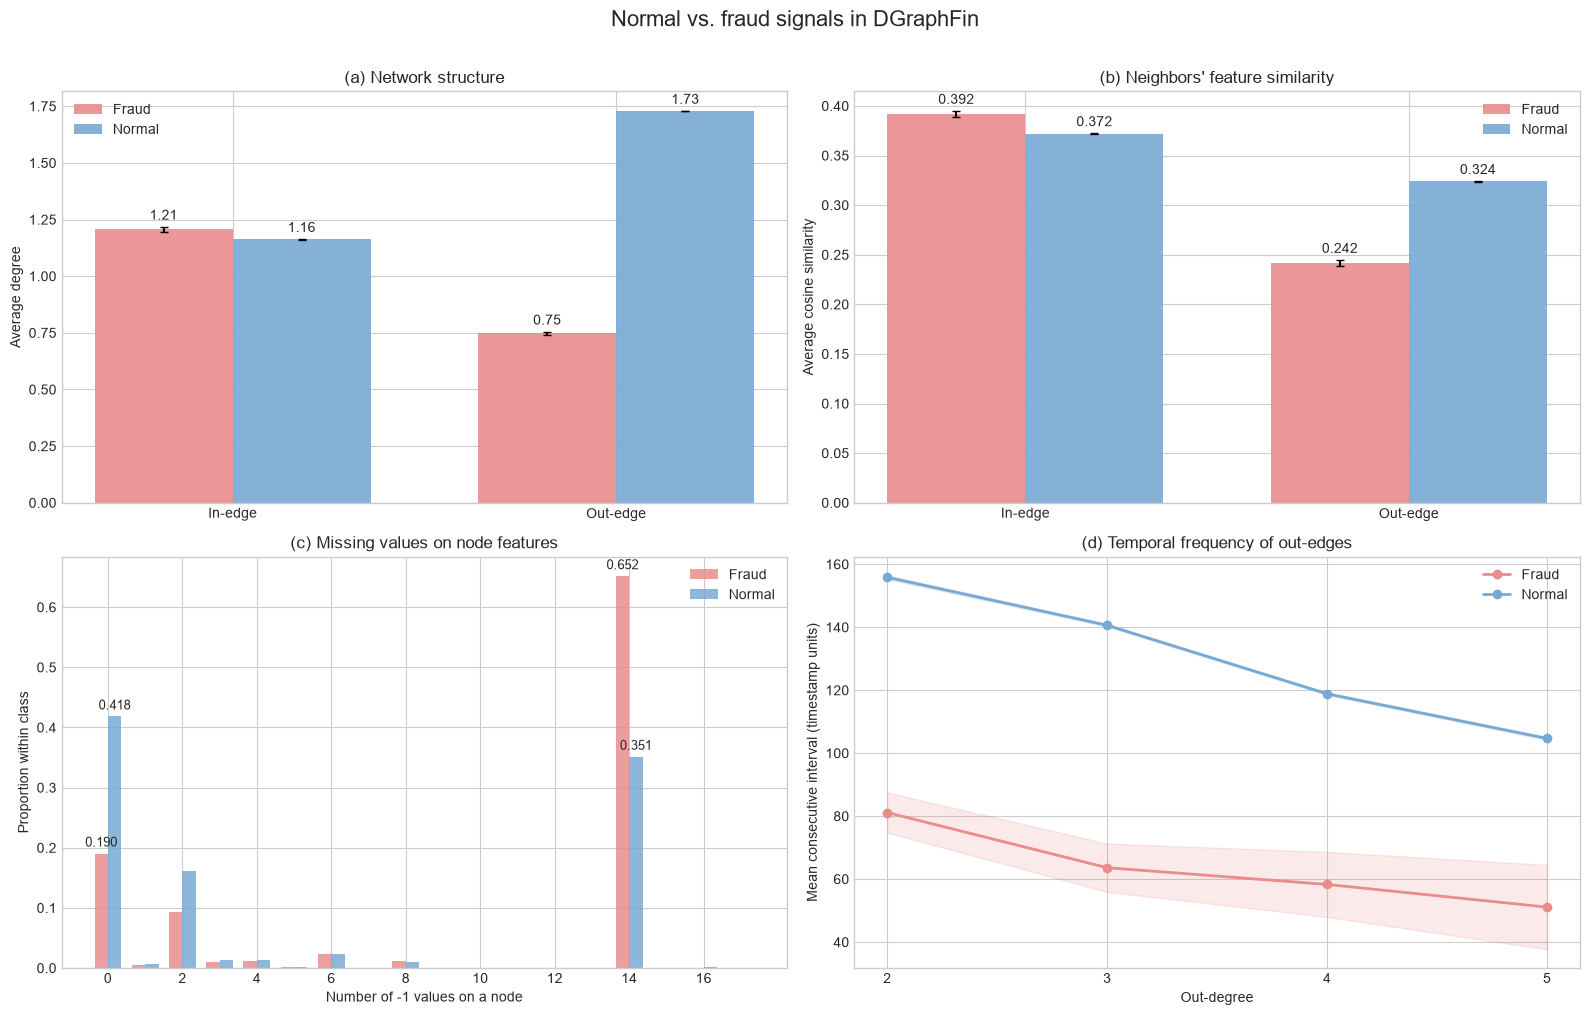

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
bar_width = 0.36
group_offsets = {"Fraud": -bar_width / 2, "Normal": bar_width / 2}


# (a) Network structure.
axis = axes[0, 0]
directions = ["In-edge", "Out-edge"]
positions = np.arange(len(directions))
for group_name in GROUP_ORDER:
    selected = structure_df[structure_df["group"] == group_name].set_index("direction").loc[directions]
    bars = axis.bar(
        positions + group_offsets[group_name],
        selected["mean_degree"],
        width=bar_width,
        yerr=selected["standard_error"],
        capsize=3,
        label=group_name,
        color=GROUP_COLORS[group_name],
        alpha=0.9,
    )
    axis.bar_label(bars, fmt="%.2f", padding=3)
axis.set_xticks(positions, directions)
axis.set_ylabel("Average degree")
axis.set_title("(a) Network structure")
axis.legend()


# (b) Paper-style neighbor similarity, including zero for a missing direction.
axis = axes[0, 1]
for group_name in GROUP_ORDER:
    selected = similarity_df[similarity_df["group"] == group_name].set_index("direction").loc[directions]
    bars = axis.bar(
        positions + group_offsets[group_name],
        selected["paper_style_mean"],
        width=bar_width,
        yerr=selected["standard_error"],
        capsize=3,
        label=group_name,
        color=GROUP_COLORS[group_name],
        alpha=0.9,
    )
    axis.bar_label(bars, fmt="%.3f", padding=3)
axis.set_xticks(positions, directions)
axis.set_ylabel("Average cosine similarity")
axis.set_title("(b) Neighbors' feature similarity")
axis.legend()


# (c) Distribution of the number of missing sentinels per node.
axis = axes[1, 0]
missing_positions = np.arange(FEATURE_DIMENSION + 1)
for group_name in GROUP_ORDER:
    selected = (
        missing_distribution_df[missing_distribution_df["group"] == group_name]
        .set_index("missing_count")
        .reindex(missing_positions, fill_value=0)
    )
    axis.bar(
        missing_positions + group_offsets[group_name],
        selected["proportion"],
        width=bar_width,
        label=group_name,
        color=GROUP_COLORS[group_name],
        alpha=0.85,
    )
    for missing_count in (0, 14):
        value = float(selected.loc[missing_count, "proportion"])
        axis.annotate(
            f"{value:.3f}",
            (missing_count + group_offsets[group_name], value),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            fontsize=9,
        )
axis.set_xticks(np.arange(0, FEATURE_DIMENSION + 1, 2))
axis.set_xlabel("Number of -1 values on a node")
axis.set_ylabel("Proportion within class")
axis.set_title("(c) Missing values on node features")
axis.legend()


# (d) Mean consecutive timestamp gap; shaded band is a 95% normal CI.
axis = axes[1, 1]
for group_name in GROUP_ORDER:
    selected = temporal_interval_df[temporal_interval_df["group"] == group_name].sort_values("out_degree")
    degree_values = selected["out_degree"].to_numpy()
    mean_values = selected["mean_interval"].to_numpy()
    confidence = 1.96 * selected["standard_error"].to_numpy()
    axis.plot(
        degree_values,
        mean_values,
        marker="o",
        linewidth=2,
        label=group_name,
        color=GROUP_COLORS[group_name],
    )
    axis.fill_between(
        degree_values,
        mean_values - confidence,
        mean_values + confidence,
        color=GROUP_COLORS[group_name],
        alpha=0.18,
    )
axis.set_xticks([2, 3, 4, 5])
axis.set_xlabel("Out-degree")
axis.set_ylabel("Mean consecutive interval (timestamp units)")
axis.set_title("(d) Temporal frequency of out-edges")
axis.legend()


fig.suptitle("Normal vs. fraud signals in DGraphFin", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# Release large temporary arrays before the sampling benchmark below.
del neighbor_in_similarity, neighbor_out_similarity, missing_per_node

### Nhận xét

- **Cấu trúc:** fraud và normal có in-degree trung bình gần nhau, nhưng out-degree của
  normal cao hơn rõ rệt (`1,73` so với `0,75`). Cấu trúc graph vì vậy chứa tín hiệu
  phân biệt mà feature của từng node riêng lẻ không thể hiện hết.
- **Hàng xóm:** thống kê theo paper cho thấy fraud có similarity thấp hơn normal trên
  out-edge (`0,242` so với `0,324`). Vì node không có hàng xóm theo một hướng được gán
  similarity bằng 0, thống kê này kết hợp cả tỷ lệ có hàng xóm và độ giống feature.
  Cột `connected_node_mean` trong bảng tách riêng similarity trên các node thực sự có
  hàng xóm để tránh diễn giải quá mức.
- **Missing value:** `41,8%` normal nhưng chỉ `19,0%` fraud không có giá trị `-1`;
  ngược lại, nhóm có 14 missing value chiếm `65,2%` fraud và `35,1%` normal. Điều này
  tạo cơ sở thực nghiệm cho ablation zero-indicator ở Sprint 2.
- **Thời gian:** trong cùng một out-degree từ 2 đến 5, fraud có khoảng cách thời gian
  giữa các out-edge thấp hơn normal. Đây là tín hiệu để nghiên cứu temporal modeling
  ở sprint sau, không có nghĩa notebook hiện tại đã huấn luyện temporal GNN.

Bốn panel cho thấy graph structure, neighbor context, missing pattern và thời gian đều
có khả năng hỗ trợ phân biệt fraud. Chúng chưa chứng minh riêng yếu tố nào làm model tốt
hơn; kết luận về hiệu quả model vẫn phải dựa trên thí nghiệm có kiểm soát.

## 7. Benchmark directed neighbor sampling

Sampler fallback dưới đây dựng CSR theo **destination node** và lấy incoming neighbor
cho message flow `source → target`. Fan-out `[15, 10]` khớp với hai GNN layer.

In [18]:
@dataclass(frozen=True, slots=True)
class NeighborSamplingPolicy:
    num_neighbors: tuple[int, ...] = (15, 10)
    batch_size: int = 1024
    seed: int = 42

    def validate(self) -> None:
        if not self.num_neighbors or any(value <= 0 for value in self.num_neighbors):
            raise ValueError("num_neighbors phải gồm các số nguyên dương")
        if self.batch_size <= 0:
            raise ValueError("batch_size phải dương")


@dataclass(frozen=True, slots=True)
class SampledSubgraph:
    nodes: np.ndarray
    edge_index: np.ndarray
    seed_nodes: np.ndarray
    hop_edge_counts: tuple[int, ...]


class DirectedNeighborSampler:
    """Sample incoming neighbors while preserving source-to-target direction."""

    def __init__(self, edge_index: np.ndarray, num_nodes: int, policy: NeighborSamplingPolicy):
        policy.validate()
        if edge_index.ndim != 2 or edge_index.shape[1] != 2:
            raise ValueError("edge_index phải có shape (E, 2)")
        self.policy = policy
        self.num_nodes = num_nodes

        source, target = edge_index[:, 0], edge_index[:, 1]
        order = np.argsort(target, kind="stable")
        self.neighbors = np.asarray(source[order], dtype=np.int64)
        counts = np.bincount(target, minlength=num_nodes)
        self.indptr = np.empty(num_nodes + 1, dtype=np.int64)
        self.indptr[0] = 0
        np.cumsum(counts, out=self.indptr[1:])

    @property
    def index_nbytes(self) -> int:
        return int(self.neighbors.nbytes + self.indptr.nbytes)

    def sample(self, seed_nodes: np.ndarray, seed: int | None = None) -> SampledSubgraph:
        seeds = np.unique(np.asarray(seed_nodes, dtype=np.int64))
        if seeds.size == 0:
            raise ValueError("seed_nodes không được rỗng")
        if int(seeds.min()) < 0 or int(seeds.max()) >= self.num_nodes:
            raise ValueError("seed_nodes chứa ID ngoài miền hợp lệ")

        rng = np.random.default_rng(self.policy.seed if seed is None else seed)
        frontier = seeds
        all_sources, all_targets, hop_edge_counts = [], [], []
        for fanout in self.policy.num_neighbors:
            hop_sources, hop_targets = [], []
            for target in frontier:
                start, end = int(self.indptr[target]), int(self.indptr[target + 1])
                candidates = self.neighbors[start:end]
                chosen = (
                    candidates[rng.choice(candidates.size, fanout, replace=False)]
                    if candidates.size > fanout
                    else candidates
                )
                if chosen.size:
                    hop_sources.append(chosen)
                    hop_targets.append(np.full(chosen.size, target, dtype=np.int64))

            if not hop_sources:
                hop_edge_counts.append(0)
                frontier = np.empty(0, dtype=np.int64)
                continue
            sources, targets = np.concatenate(hop_sources), np.concatenate(hop_targets)
            all_sources.append(sources)
            all_targets.append(targets)
            hop_edge_counts.append(int(sources.size))
            frontier = np.unique(sources)

        if all_sources:
            sources, targets = np.concatenate(all_sources), np.concatenate(all_targets)
            nodes = np.unique(np.concatenate((seeds, sources, targets)))
            local_edges = np.stack((np.searchsorted(nodes, sources), np.searchsorted(nodes, targets)))
        else:
            nodes = seeds
            local_edges = np.empty((2, 0), dtype=np.int64)
        return SampledSubgraph(nodes, local_edges, seeds, tuple(hop_edge_counts))

In [19]:
policy = NeighborSamplingPolicy()
index_started = time.perf_counter()
sampler = DirectedNeighborSampler(dataset.edge_index, dataset.num_nodes, policy)
index_seconds = time.perf_counter() - index_started

sample_started = time.perf_counter()
sampled = sampler.sample(dataset.train_mask[: policy.batch_size])
sample_seconds = time.perf_counter() - sample_started

sampling_benchmark = {
    "policy": {
        "direction": "incoming (source -> target)",
        "fanout": list(policy.num_neighbors),
        "batch_size": policy.batch_size,
        "seed": policy.seed,
    },
    "timing_seconds": {
        "load_dataset": load_seconds,
        "build_csr_index": index_seconds,
        "sample_one_batch": sample_seconds,
    },
    "memory_bytes": {
        "canonical_numpy_arrays": sum(array.nbytes for array in arrays.values()),
        "sampler_csr_index": sampler.index_nbytes,
    },
    "sample": {
        "seed_node_count": int(sampled.seed_nodes.size),
        "sampled_node_count": int(sampled.nodes.size),
        "sampled_edge_count": int(sampled.edge_index.shape[1]),
        "hop_edge_counts": list(sampled.hop_edge_counts),
    },
    "versions": {"numpy": np.__version__},
}
display(pd.json_normalize(sampling_benchmark))
(METRIC_DIR / "sprint1_sampling_benchmark.json").write_text(
    json.dumps(sampling_benchmark, ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)

,policy.direction,policy.fanout,policy.batch_size,policy.seed,timing_seconds.load_dataset,timing_seconds.build_csr_index,timing_seconds.sample_one_batch,memory_bytes.canonical_numpy_arrays,memory_bytes.sampler_csr_index,sample.seed_node_count,sample.sampled_node_count,sample.sampled_edge_count,sample.hop_edge_counts,versions.numpy
0,incoming (source -> target),"[15, 10]",1024,42,0.573826,0.571783,0.00341,428678576,64012400,1024,3207,2341,"[1282, 1059]",2.5.1


615

## 8. Lưu evidence và dataset fingerprint

SHA-256 bảo đảm các sprint sau đang dùng đúng file dữ liệu đã được EDA ở đây.

In [20]:
def file_sha256(path: str | Path, chunk_size: int = 1024 * 1024) -> str:
    """Hash a large file without reading it into memory a second time."""
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for chunk in iter(lambda: stream.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


profile_artifact = {
    "source": DATA_PATH.relative_to(PROJECT_ROOT).as_posix(),
    "sha256": file_sha256(DATA_PATH),
    "validation": validation.as_dict(),
    "profile": profile,
}
(METRIC_DIR / "sprint1_data_profile.json").write_text(
    json.dumps(profile_artifact, ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)
print("SHA-256:", profile_artifact["sha256"])
print("Artifact:", (METRIC_DIR / "sprint1_data_profile.json").relative_to(PROJECT_ROOT).as_posix())

SHA-256: 95470dab2c48523f7118a92204c090de37a957bb053bd5841c7bdba09558ba85
Artifact: artifacts/metrics/sprint1_data_profile.json


## 9. Kết luận Sprint 1

- Dataset hợp lệ; ba split không chồng lấn và chỉ chứa nhãn mục tiêu `0/1`.
- Fraud rate khoảng 1,27%, vì vậy Sprint 2 chọn checkpoint bằng validation AP và
  không dùng test để lựa chọn.
- `-1` xuất hiện với tỷ lệ khác nhau giữa các feature; Sprint 2 so sánh raw 17D với
  zero-indicator 34D thay vì tự động coi `-1` là giá trị số thông thường.
- Graph canonical giữ hướng gốc, background node, 11 edge type và timestamp.
- Neighbor sampling `[15, 10]`, batch 1.024 là cấu hình khởi đầu phù hợp cho CPU.